# Tarea 2: Modelos de variable latente y GANs
## MDS7203 Modelos Generativos Profundos
### Magíster en Ciencia de Datos - Universidad de Chile
#### Otoño, 2026

**Nombre:**

**Fecha de entrega:**

En esta segunda tarea se implementarán dos modelos generativos importantes utilizando el dataset [**Bingsu/Gameplay_Images**](https://huggingface.co/datasets/Bingsu/Gameplay_Images), el cual está formado por un conjunto de capturas de pantalla de videojuegos populares.

La tarea se divide en tres partes:

1. [**VQ-VAE:**](https://arxiv.org/abs/1711.00937) se implementará un autoencoder variacional con cuantización vectorial (Vector Quantized VAE), el cual aprende un espacio latente discreto, permitiendo posteriormente una generación autorregresiva.
2. [**VQ-GAN:**](https://arxiv.org/abs/2012.09841) se reciclará el backbone del VQ-VAE y se modificará la función de pérdida para incluir una penalización adversarial (tipo GAN) y una pérdida perceptual (LPIPS). Esto permitirá generar imágenes de mayor calidad y fidelidad visual.
3. **Prior autorregresivo (GPT):** se entrenará un transformer causal sobre los tokens discretos de la VQ-GAN para generar imágenes nuevas de manera autorregresiva.

**Instrucciones generales:**
- La tarea debe ejecutarse en **Google Colab con una GPU NVIDIA Tesla T4**.
- Se permite el uso libre de asistentes de IA (ChatGPT, Claude, Gemini, Copilot, etc.), pero **se debe entender en su totalidad el código entregado**.
- Se debe entregar este mismo `.ipynb` con todas las celdas ejecutadas.
- Las 3 partes de la tarea valen lo mismo (1/3 cada una).
- **Importante:** el notebook fue ejecutado sobre una NVIDIA GeForce RTX 4090. Es parte de la tarea adaptar los hiperparámetros de entrenamiento (e.g. batch size) a la GPU NVIDIA Tesla T4 que ofrece Colab. Además, no es necesario replicar el mismo número de épocas de entrenamiento.

## Configuración inicial

Se comenzará instalando las librerías necesarias:

In [ ]:
!pip install -q numpy Pillow matplotlib tqdm torch torchvision datasets lpips

La siguiente celda importa las librerías a utilizar:

In [ ]:
import gc
import random

import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import lpips
from datasets import load_dataset

/root/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Se define el dispositivo a utilizar y una función auxiliar para liberar la memoria GPU entre preguntas:

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', DEVICE)

if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

def free_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4090


# Parte 1: VQ-VAE

En esta primera parte se estudiará el **vector quantized VAE (VQ-VAE)**, un autoencoder cuyo espacio latente es discreto (i.e., a diferencia de un VAE usual, aquí hay una cantidad finita de posibles vectores latentes). Para lograr esto, cada posición espacial de la salida del encoder $E_\phi$ se reemplaza por el vector más cercano de un **codebook** aprendido, $\{e_k\}_{k=1}^{K}\subset\mathbb{R}^{L}$, el cual también puede ser visto como una _matriz_ de embeddings de un vocabulario latente finito. Esto produce, para cada imagen, una grilla de índices $k_1, \ldots, k_T \in \{1,\ldots,K\}$ (con $T = H\cdot W$ el número de posiciones espaciales de la salida del encoder) que más adelante podrá ser modelada por un transformer autoregresivo, permitiendo tener un modelo tipo GPT que genere índices de forma secuencial, los cuales luego serán mapeados a su vector correspondiente en el codebook y procesados por el decoder del VQ-VAE, logrando generar imágenes nuevas de forma autoregresiva en el espacio latente de un VAE con cuantización vectorial.

## 1.1 Dataset

A lo largo de toda la tarea se utilizará un subconjunto del dataset `Bingsu/Gameplay_Images`:

In [ ]:
class GameplayDataset(Dataset):

    LABELS = {
        'Among Us': 0, 'Apex Legends': 1, 'Fortnite': 2, 'Forza Horizon': 3,
        'Free Fire': 4, 'Genshin Impact': 5, 'God of War': 6, 'Minecraft': 7,
        'Roblox': 8, 'Terraria': 9,
    }

    def __init__(self, class_names: list[str], store_size: int = 160,
                 img_size: int = 128, augment: bool = True) -> None:
        self.class_names = class_names
        self.num_classes = len(class_names)
        self.store_size = store_size
        self.img_size = img_size
        self.augment = augment

        raw = load_dataset('Bingsu/Gameplay_Images', split='train')
        new_label = {self.LABELS[c]: i for i, c in enumerate(class_names)}
        keep = [i for i, lbl in enumerate(raw['label']) if lbl in new_label]

        images, labels = [], []
        for i in tqdm(keep, desc='Cargando'):
            img = raw[i]['image'].convert('RGB')
            side = min(img.size)
            left, top = (img.width - side) // 2, (img.height - side) // 2
            img = img.crop((left, top, left + side, top + side))
            img = img.resize((store_size, store_size), Image.BILINEAR)
            images.append(torch.from_numpy(np.asarray(img)))
            labels.append(new_label[raw[i]['label']])
        self.images = torch.stack(images)
        self.labels = torch.tensor(labels)

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        img = self.images[idx]
        margin = self.store_size - self.img_size
        if self.augment:
            top, left = random.randint(0, margin), random.randint(0, margin)
        else:
            top = left = margin // 2
        img = img[top:top + self.img_size, left:left + self.img_size]
        if self.augment and random.random() < 0.5:
            img = img.flip(1)
        return img.permute(2, 0, 1).float() / 255, self.labels[idx]

Con la clase definida, se instanciará el dataset y se construirá el dataloader respectivo.

> Sustituya el parámetro `class_names` en la siguiente instanciación de `GameplayDataset` por una lista con otros elementos de `GameplayDataset.LABELS`. Además, ajuste los hiperparámetros del dataloader para poder entrenar el modelo utilizando la GPU de Colab de manera eficiente.

Cargando:   0%|          | 0/2000 [00:00<?, ?it/s]/tmp/ipykernel_110884/3390429760.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  images.append(torch.from_numpy(np.asarray(img)))
Cargando: 100%|██████████| 2000/2000 [00:12<00:00, 159.28it/s]


Imágenes: 2000 | Batches: 15


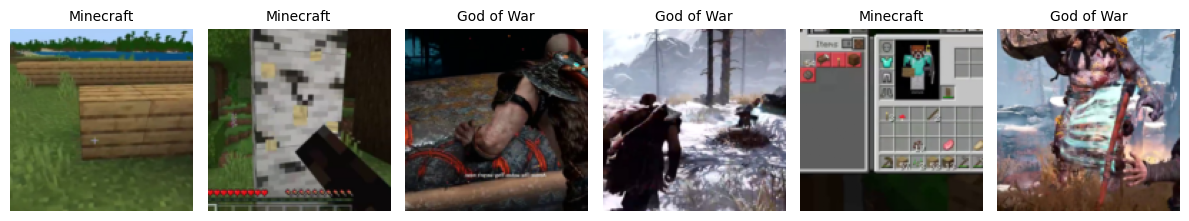

In [ ]:
dataset = GameplayDataset(class_names=['Minecraft', 'God of War'])
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2, drop_last=True)
print(f'Imágenes: {len(dataset)}')
print(f'Batches: {len(dataloader)}')

n = 6
fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
for ax, i in zip(axes, random.sample(range(len(dataset)), n)):
    img, lbl = dataset[i]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(dataset.class_names[int(lbl)], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 1.2 Arquitecturas neuronales

A continuación se explicará brevemente la arquitectura general del VQ-VAE. Como es usual, la imagen de entrada se escribirá como $x\in\mathbb{R}^{3\times 128\times 128}$ y la etiqueta de clase como $y\in\{1,\ldots,C\}$ (con $C=2$ en este caso). Sin embargo, toda la explicación se realizará para el caso incondicional ya que la extensión al caso condicional es trivial.

En VQ-VAE, el backbone se descompone en tres redes neuronales:

- Un **encoder convolucional** $E_\phi:\mathbb{R}^{3\times 128\times 128}\to\mathbb{R}^{L\times H\times W}$ que reduce la resolución por un factor 8 y produce un tensor continuo $z_e(x)=E_\phi(x)\in\mathbb{R}^{L\times H\times W}$, con $L=64$ y $H=W=16$.
- Un **cuantizador vectorial** que mapea cada posición espacial de $z_e(x)$ al vector más cercano de un codebook discreto, $\{e_k\}_{k=1}^K\subset\mathbb{R}^L$, produciendo $z_q(x)\in\mathbb{R}^{L\times H\times W}$.
- Un **decoder convolucional** $D_\theta:\mathbb{R}^{L\times H\times W}\to\mathbb{R}^{3\times 128\times 128}$ que reconstruye $\hat{x} = D_\theta(z_q(x))$ usando la representación discreta $z_q(x) \approx z_e(x)$.

Para condicionar usando la clase, se aprenden dos embeddings $b^{\text{enc}}_\phi,\,b^{\text{dec}}_\theta\in\mathbb{R}^{C\times L}$ que se suman a cada posición espacial de la salida del encoder y a cada posición espacial de la entrada del decoder, respectivamente. De esta forma, una única red neuronal cubre las $C=2$ clases del dataset.

![](vqvae.png)

La siguiente celda define el bloque residual `ResBlock` y la clase `VQVAE` que agrupa el encoder, el cuantizador y el decoder:

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.GroupNorm(32, channels), nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.GroupNorm(32, channels), nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.net(x)

class VQVAE(nn.Module):

    def __init__(self, num_codes: int = 512, code_dim: int = 64, num_classes: int = 2, ch: int = 96) -> None:
        super().__init__()
        self.num_codes = num_codes
        self.code_dim = code_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, ch, 3, padding=1),
            nn.Conv2d(ch, ch, 4, stride=2, padding=1),
            ResBlock(ch),
            nn.Conv2d(ch, 2 * ch, 4, stride=2, padding=1),
            ResBlock(2 * ch),
            nn.Conv2d(2 * ch, 2 * ch, 4, stride=2, padding=1),
            ResBlock(2 * ch), ResBlock(2 * ch),
            nn.GroupNorm(32, 2 * ch), nn.SiLU(),
            nn.Conv2d(2 * ch, code_dim, 1),
        )
        self.quantizer = VectorQuantizer(num_codes, code_dim)
        self.decoder = nn.Sequential(
            nn.Conv2d(code_dim, 2 * ch, 1),
            ResBlock(2 * ch), ResBlock(2 * ch),
            nn.ConvTranspose2d(2 * ch, 2 * ch, 4, stride=2, padding=1),
            ResBlock(2 * ch),
            nn.ConvTranspose2d(2 * ch, ch, 4, stride=2, padding=1),
            ResBlock(ch),
            nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1),
            nn.GroupNorm(32, ch), nn.SiLU(),
            nn.Conv2d(ch, 3, 3, padding=1),
        )
        self.class_emb_enc = nn.Embedding(num_classes, code_dim)
        self.class_emb_dec = nn.Embedding(num_classes, code_dim)
        nn.init.zeros_(self.class_emb_enc.weight)
        nn.init.zeros_(self.class_emb_dec.weight)

    def encode(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return self.encoder(x) + self.class_emb_enc(y).view(-1, self.code_dim, 1, 1)

    def decode(self, quantized: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return self.decoder(quantized + self.class_emb_dec(y).view(-1, self.code_dim, 1, 1))

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        encoded = self.encode(x, y)
        quantized, vq_loss, indices = self.quantizer(encoded)
        return self.decode(quantized, y), vq_loss, indices

## 1.3 Cuantización vectorial

En VQ-VAE, el codebook es un conjunto finito de vectores aprendidos $\{e_k\}_{k=1}^{K}\subset\mathbb{R}^{L}$ (con $K=512$, $L=64$), inicializados uniformemente en $[-1/K,\,1/K]$. La salida del encoder $z_e(x)\in\mathbb{R}^{L\times H\times W}$ es una grilla de $H\cdot W$ vectores, donde $z_e(x)_{hw}\in\mathbb{R}^{L}$ denota el vector de la posición espacial $(h,w)$. Cada posición espacial se cuantiza de forma independiente, reemplazándose por su vector más cercano en el codebook siguiendo un enfoque tipo $K$-means. Es decir, para cada posición espacial $(h,w)\in\{1,\ldots,H\}\times\{1,\ldots,W\}$:

$$
  z_q(x)_{hw} = e_{k^*_{hw}},
\quad\text{donde}\quad
  k^*_{hw} = \operatorname{argmin}_{j\in\{1,\ldots,K\}} \|z_e(x)_{hw} - e_j\|_2,
$$

De este modo, se obtiene una grilla cuantizada $z_q(x)\in\mathbb{R}^{L\times H\times W}$ compuesta únicamente por vectores del codebook, y una grilla de índices $k^*_{hw}\in\{1,\ldots,K\}$ que indica qué código se eligió en cada posición espacial.

Al igual que en un VAE estándar, la función objetivo de un VQ-VAE se puede derivar a partir de la ELBO. Como cada posición espacial se cuantiza de forma independiente, la posterior sobre la grilla completa factoriza como un producto de posteriores por posición:

$$
q_\phi(z|x) = \prod_{h=1}^{H}\prod_{w=1}^{W} q_\phi(z_{hw}|x),
\quad\text{donde}\quad q_\phi(z_{hw}|x) = \delta_{e_{k^*_{hw}}}
$$

Tomando un prior uniforme e independiente por posición, $p(z) = \prod_{h,w} p(z_{hw})$, con $p(z_{hw}=e_k)=1/K$ para todo $k$, el término de prior matching de la ELBO resulta constante. En efecto, como ambas distribuciones factorizan sobre las posiciones, la divergencia de Kullback-Leibler se descompone en una suma:

$$
  \operatorname{D}_\text{KL}\big(q_\phi(z|x)\,\big\|\,p(z)\big)
  = \sum_{h=1}^{H}\sum_{w=1}^{W}\operatorname{D}_\text{KL}\big(q_\phi(z_{hw}|x)\,\big\|\,p(z_{hw})\big),
$$

donde cada sumando por sí solo es constante:

$$
  \operatorname{D}_\text{KL}\big(q_\phi(z_{hw}|x)\,\big\|\,p(z_{hw})\big)
  = \mathbb{E}_{z_{hw}\sim q_\phi(z_{hw}|x)}\left[\log\frac{q_\phi(z_{hw}|x)}{p(z_{hw})}\right]
  = \log\frac{q_\phi(e_{k^*_{hw}}|x)}{p(e_{k^*_{hw}})}
  = \log\frac{1}{1/K}
  = \log K.
$$

Luego, $\operatorname{KL}\big(q_\phi(z|x)\,\big\|\,p(z)\big) = H\cdot W\,\log K$, por lo que se puede omitir este término en la optimización.

Con respecto al término de reconstrucción, el determinismo de $q_\phi(z|x)$ implica que $\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] = \log p_\theta(x|z_q(x))$. Luego, asumiendo un decoder gaussiano, $p_\theta(x|z)=\mathcal{N}(\mu_\theta(z),\text{I}_D)$, se tiene que $-\log p_\theta(x|z_q(x))$ es proporcional al error cuadrático entre $x$ y la reconstrucción $\hat{x}=\mu_\theta(z_q(x))$.

Por otro lado, $\operatorname{argmin}$ no es diferenciable, por lo que no es posible actualizar el codebook $\{e_k\}_{k=1}^{K}$ ni el encoder $E_\phi$ mediante backpropagation (ya que al cuantizar se pierde el gradiente). Para solucionar esto, VQ-VAE añade dos términos adicionales que permiten actualizar ambos componentes. Luego, un VQ-VAE es entrenado minimizando el promedio sobre el trainset de la siguiente función de pérdida:

$$
  \mathcal{L}_\text{VQ-VAE}(x)
  = \underbrace{\|x-\hat{x}\|_2^2}_{\text{reconstrucción}}
  + \underbrace{\big\|\text{sg}[z_e(x)] - z_q(x)\big\|_2^2}_{\text{codebook loss}}
  + \underbrace{\beta\,\big\|z_e(x) - \text{sg}[z_q(x)]\big\|_2^2}_{\text{commitment loss}},
$$

donde las normas se entienden sumando sobre todas las posiciones espaciales de la grilla. Aquí, $\text{sg}$ es el operador **stop-gradient** (i.e., $\text{sg}[u]=u$ durante el forward y $\partial\,\text{sg}[u]/\partial u = 0$ durante el backward), el cual equivale a `tensor.detach()` en PyTorch. Por lo tanto, la codebook loss solo actualiza el codebook, moviendo cada código elegido, $e_{k^*_{hw}}$, hacia el encoding original asociado, $z_e(x)_{hw}$. De forma análoga, la commitment loss solo actualiza el encoder, manteniéndolo cerca de los códigos elegidos.

Además, dado que $\operatorname{argmin}$ interrumpe el flujo del gradiente, es necesario copiar el gradiente del decoder hacia el encoder para que este último también reciba señal de aprendizaje. Para esto se utiliza el **straight-through estimator**, que en el forward usa $z_q(x)$ pero en el backward copia el gradiente directamente sobre $z_e(x)$, sin modificar la función de pérdida ni el proceso de optimización:

$$
  z_q(x) \leftarrow z_e(x) + \text{sg}[z_q(x) - z_e(x)]
$$

### Códigos muertos y revival

Un problema usual en la formulación anterior es el colapso del codebook, donde los códigos que al inicio quedan lejos del soporte de $x\mapsto z_e(x)$ nunca son elegidos por $\operatorname{argmin}$, por lo que la codebook loss nunca los actualiza y quedan congelados en su inicialización. De este modo, con el avance del entrenamiento, solo una fracción de los códigos es utilizada, lo que limita la capacidad de representación del modelo y dificulta el posterior entrenamiento del prior autorregresivo, ya que este tendrá que aprender a generar imágenes usando un vocabulario efectivo más pequeño y con muchos códigos sin uso.

Para evitar este problema se puede implementar un mecanismo de **dead code revival**:

1. Se mantiene una media móvil exponencial del número de veces que cada código es elegido:
$$
  N_k \leftarrow \gamma\,N_k + (1-\gamma)\,n_k,
  \quad\text{donde}\quad
  n_k = \sum_{i,h,w} \mathbf{1}\{k^*_{i,h,w} = k\}
$$
   Notar que $n_k\in\mathbb{N}$ cuenta la cantidad de selecciones del código $e_k$ en alguna posición espacial de alguna imagen del batch en curso.

2. Cada `revive_every` pasos, los códigos $e_k\in\mathbb{R}^L$ cuyo EMA $N_k\geq 0$ esté por debajo del umbral `dead_threshold` se consideran muertos y se reemplazan por vectores $z_e(x)_{hw}\in\mathbb{R}^L$ tomados al azar del batch en curso. Así, estos códigos vuelven a estar en el soporte del encoder y pueden volver a competir en el $\operatorname{argmin}$ en los pasos siguientes.

Este mecanismo es estándar en implementaciones modernas de VQ-VAE/VQ-GAN y suele subir el uso del codebook al $80$–$100\%$ sin modificar el resto del entrenamiento.

> Implemente la clase `VectorQuantizer`, cuyo método `forward` recibe un tensor `encoded` de tamaño $(B, L, H, W)$ y debe devolver:
> 1. `quantized`: el tensor cuantizado del mismo tamaño, con el straight-through estimator aplicado.
> 2. `vq_loss`: la suma `codebook_loss + beta * commitment_loss`.
> 3. `indices`: los índices elegidos en el argmin, de tamaño $(B, H, W)$.
>>
> Adicionalmente, incorpore el mecanismo de revival descrito arriba. Considere que el loop de entrenamiento muestra cuántos códigos se revivieron en cada época leyendo un atributo `last_revived` del cuantizador, por lo que su implementación debe exponerlo.

In [ ]:
class VectorQuantizer(nn.Module):

    def __init__(self, num_codes: int, code_dim: int, beta: float = 0.25, decay: float = 0.99, dead_threshold: float = 1.0, revive_every: int = 25) -> None:
        ...

    def forward(self, encoded: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        ...

    @torch.no_grad()
    def _revive_dead_codes(self, flat: torch.Tensor) -> None:
        ...

## 1.4 Entrenamiento

Como el `VectorQuantizer` ya devuelve la suma de la codebook loss y la commitment loss, el loop de entrenamiento sólo necesita sumarle el término de reconstrucción y optimizar el promedio sobre el conjunto de entrenamiento $\mathcal{D}$:

$$
  \min_{\phi,\,\theta,\,\{e_k\}_{k=1}^{K}}\;\frac{1}{|\mathcal{D}|}\sum_{x\in\mathcal{D}} \mathcal{L}_\text{VQ-VAE}(x),
$$

donde la optimización entrena en conjunto el encoder $E_\phi$, el decoder $D_\theta$ y el codebook $\{e_k\}_{k=1}^{K}$. El siguiente método permite entrenar un VQ-VAE usando la función objetivo anterior adaptada al caso condicional:

In [ ]:
def train_vqvae(model: VQVAE, dataloader: DataLoader, epochs: int, lr: float = 3e-4) -> list[float]:
    model.to(DEVICE).train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = []
    pbar = tqdm(range(epochs), desc='VQ-VAE')
    try:
        for _ in pbar:
            used = set()
            revived = 0
            for x, y in dataloader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                x_hat, vq_loss, indices = model(x, y)
                loss = F.mse_loss(x_hat, x) + vq_loss
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                history.append(loss.item())
                used.update(indices.unique().tolist())
                revived += model.quantizer.last_revived
            alive = 100 * len(used) / model.num_codes
            pbar.set_postfix(loss=f'{history[-1]:.4f}', alive=f'{alive:.0f}%', revived=revived)
    except KeyboardInterrupt:
        print('Entrenamiento interrumpido.')
    torch.save({'model_state_dict': model.state_dict(), 'loss_history': history}, 'vqvae.pth')
    return history

Con el método anterior implementado, se puede instanciar el modelo y entrenarlo:

In [ ]:
vqvae = VQVAE(num_codes=512, code_dim=64, num_classes=dataset.num_classes, ch=96)
print(f'Parámetros VQ-VAE: {sum(p.numel() for p in vqvae.parameters())/1e6:.2f} M')

train_vqvae(vqvae, dataloader, epochs=500)
free_memory()

Parámetros VQ-VAE: 6.45 M


VQ-VAE: 100%|██████████| 500/500 [22:03<00:00,  2.65s/it, alive=100%, loss=0.0055, revived=0] 


Una vez entrenado, se puede cargar el checkpoint, visualizar la dinámica de entrenamiento y mostrar algunas reconstrucciones:

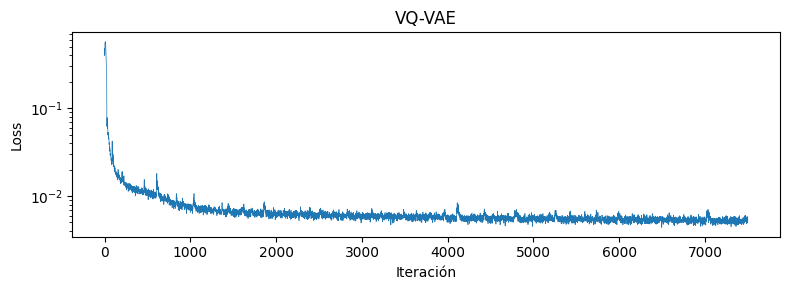

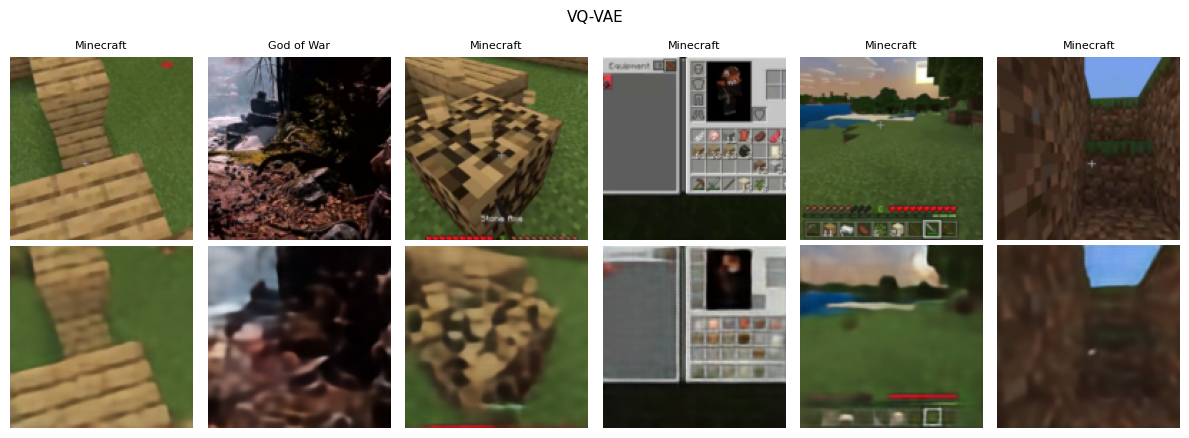

In [ ]:
vqvae = VQVAE(num_codes=512, code_dim=64, num_classes=dataset.num_classes, ch=96)
ckpt  = torch.load('vqvae.pth', map_location=DEVICE, weights_only=False)
vqvae.load_state_dict(ckpt['model_state_dict'])
vqvae.to(DEVICE).eval()

plt.figure(figsize=(8, 3))
plt.plot(ckpt['loss_history'], linewidth=0.5)
plt.xlabel('Iteración'); plt.ylabel('Loss'); plt.yscale('log'); plt.title('VQ-VAE')
plt.tight_layout(); plt.show()

@torch.no_grad()
def show_reconstructions(model: VQVAE, n: int = 6, title: str = '') -> None:
    sel = random.sample(range(len(dataset)), n)
    batch = [dataset[i] for i in sel]
    x = torch.stack([b[0] for b in batch])
    y = torch.tensor([int(b[1]) for b in batch])
    x_hat, _, _ = model(x.to(DEVICE), y.to(DEVICE))
    x_hat = x_hat.cpu().clamp(0, 1)
    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4.5))
    for j in range(n):
        axes[0, j].imshow(x[j].permute(1, 2, 0)); axes[0, j].axis('off')
        axes[0, j].set_title(dataset.class_names[int(y[j])], fontsize=8)
        axes[1, j].imshow(x_hat[j].permute(1, 2, 0)); axes[1, j].axis('off')
    axes[0, 0].set_ylabel('Original'); axes[1, 0].set_ylabel('Reconstrucción')
    if title: plt.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

show_reconstructions(vqvae, title='VQ-VAE')

del vqvae, ckpt
free_memory()

# Parte 2: VQ-GAN

En esta segunda parte se implementará una VQ-GAN, la cual utiliza el mismo backbone que VQ-VAE pero cambia la función de pérdida por una combinación de pérdida $\ell_1$, LPIPS perceptual y PatchGAN adversarial. Además, se incluye un peso adaptativo que equilibra los términos según la norma de sus gradientes. Dado que el generador reutiliza el backbone del VQ-VAE (encoder, cuantizador y decoder de la clase `VQVAE`), sólo es necesario implementar el discriminador que requiere el término de pérdida adversarial de la VQ-GAN.

## 2.1 Discriminador PatchGAN

Dado que el entrenamiento adversarial necesita un modelo discriminativo para la clasificación real/sintético, VQ-GAN utiliza la misma idea de Pix2Pix para el discriminador, donde la clasificación se realiza sobre parches locales de la imagen en vez de la imagen completa. Más precisamente, el discriminador es una red neuronal completamente convolucional, $F_\gamma:\mathbb{R}^{3\times 128\times 128}\to\mathbb{R}^{1\times 15\times 15}$, donde cada elemento espacial de la salida clasifica como verdadero o sintético una región local de la entrada, en lugar de devolver un único valor global que clasifique toda la imagen (notar que el discriminador se está denotando como $F_\gamma$ en vez de $D_\theta$ para diferenciarlo del decoder del VQ-VAE).

La siguiente clase `PatchDiscriminator` implementa una CNN siguiendo las indicaciones de DCGAN:

In [ ]:
class PatchDiscriminator(nn.Module):

    def __init__(self, ch: int = 64) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ch, 4, stride=2, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(ch, 2 * ch, 4, stride=2, padding=1),
            nn.BatchNorm2d(2 * ch), nn.LeakyReLU(0.2),
            nn.Conv2d(2 * ch, 4 * ch, 4, stride=2, padding=1),
            nn.BatchNorm2d(4 * ch), nn.LeakyReLU(0.2),
            nn.Conv2d(4 * ch, 1, 4, padding=1),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

## 2.2 Loop de entrenamiento adversarial

Como es usual en una GAN, el generador (en este caso, el VQ-VAE) y el discriminador $F_\gamma$ se entrenan de forma alternada. En el caso de VQ-GAN, el discriminador es entrenado utilizando la hinge loss, donde el entrenamiento empuja la salida de muestras reales hacia $+1$ y la salida de muestras sintéticas hacia $-1$:

$$
  \mathcal{L}_\text{hinge}
  = \tfrac{1}{2}\,\mathbb{E}_{p_\text{data}(x)}\left[\max(0,\,1 - F_\gamma(x))\right]
  + \tfrac{1}{2}\,\mathbb{E}_{p_\text{data}(x)}\left[\max(0,\,1 + F_\gamma(D_\theta(z_q(x))))\right]
$$

Como $F_\gamma(x)$ es un feature map de $15\times15$ parches, cada $\max(0,\cdot)$ se aplica elemento a elemento y luego se promedia sobre las posiciones del feature map (además del promedio sobre el batch).

Por otro lado, para el generador, la pérdida de reconstrucción combina un término a nivel de pixeles con un penalizador perceptual:

$$
  \mathcal{L}_\text{rec}(x) = \|x - \hat{x}\|_1 + \mathcal{L}_\text{LPIPS}(x, \hat{x}),
$$

donde $\hat{x} = D_\theta(z_q(x))$ es la reconstrucción del VQ-VAE y $\mathcal{L}_\text{LPIPS}$ es la **distancia perceptual LPIPS**, la cual calcula la diferencia cuadrática de ciertas features de $\hat{x}$ y $x$, las cuales son obtenidas usando una VGG (CNN clásica para clasificación sobre ImageNet) preentrenada con sus parámetros congelados. Es importante considerar que LPIPS espera entradas en $[-1, 1]$, por lo que se deben reescalar $x$ y $\hat{x}$ antes de la obtención de las features.

Además, como es usual en una GAN, el generador también se entrena para engañar al discriminador, por lo que se incluye el término adversarial no saturante:

$$
  \mathcal{L}_\text{GAN}
  = -\,\mathbb{E}_{p_\text{data}(x)}\left[F_\gamma(D_\theta(z_q(x)))\right]
$$

Con esto, la función objetivo del generador, optimizado de forma conjunta sobre el encoder $E_\phi$, el codebook $\{e_k\}_{k=1}^K$ y el decoder $D_\theta$, es la siguiente:

$$
  \mathcal{L}_\text{G}
  = \mathcal{L}_\text{rec}(x) + \mathcal{L}_\text{VQ}(x)
  + \lambda_\text{disc}\cdot\lambda_\text{adapt}\cdot\mathcal{L}_\text{GAN},
$$

donde $\mathcal{L}_\text{VQ}(x)$ es la suma codebook loss $+$ commitment loss definida en la Parte 1, y el **peso adaptativo** $\lambda_\text{adapt} \geq 0$ se calcula como el cociente entre las normas del gradiente de la reconstrucción y el gradiente de la GAN, ambos respecto a la última capa $\theta_N$ del decoder:

$$
  \lambda_\text{adapt} = \frac{\|\nabla_{\theta_N}\,\mathcal{L}_\text{rec}\|_2}{\|\nabla_{\theta_N}\,\mathcal{L}_\text{GAN}\|_2}
$$

De esta forma, la magnitud del gradiente adversarial queda automáticamente alineada con la de la reconstrucción, y la GAN nunca domina al objetivo perceptual. Para evitar inestabilidades al inicio del entrenamiento (cuando $D_\theta$ aún no produce reconstrucciones reconocibles), el término adversarial se activa recién después de un warmup equivalente a una fracción `disc_start_frac` del total de iteraciones. Por otro lado, el coeficiente fijo adicional $\lambda_\text{disc}\in[0,1]$ pondera el término adversarial junto al peso adaptativo.

> Implemente la función `train_vqgan` que recibe el modelo, el discriminador y el dataloader, y entrena ambos de forma alternada según las pérdidas descritas. Utilice `lpips.LPIPS(net='vgg')` como red perceptual (recordar congelar sus parámetros), `torch.autograd.grad` para calcular el peso adaptativo, y dos optimizadores AdamW independientes con `betas=(0.5, 0.9)`. Como retorno, la función debe entregar una lista de tuplas, con cada tupla conteniendo la pérdida $l_1$, la pérdida perceptual, la pérdida adversarial y la pérdida del discriminador.

In [ ]:
def train_vqgan(model: VQVAE, disc: PatchDiscriminator, dataloader: DataLoader, epochs: int,
                lr: float = 2e-4, disc_start_frac: float = 0.25,
                disc_weight: float = 0.8) -> list[tuple[float, float, float, float]]:
    ...

La siguiente celda instancia el generador y el discriminador, y los entrena. A diferencia del VQ-VAE, aquí el entrenamiento también mantiene en GPU el discriminador y la red perceptual LPIPS (VGG), por lo que es posible que se necesite bajar el batch size respecto al usado en la Parte 1 para evitar errores de memoria. Por ello, reinstancie el dataloader con un batch size más pequeño antes de entrenar:

In [ ]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2, drop_last=True)

vqgan = VQVAE(num_codes=512, code_dim=64, num_classes=dataset.num_classes, ch=96)
disc  = PatchDiscriminator(ch=64)
print(f'Parámetros generador:     {sum(p.numel() for p in vqgan.parameters())/1e6:.2f} M')
print(f'Parámetros discriminador: {sum(p.numel() for p in disc.parameters())/1e6:.2f} M')

train_vqgan(vqgan, disc, dataloader, epochs=500)

del disc
free_memory()

Parámetros generador:     6.45 M
Parámetros discriminador: 0.66 M


VQ-GAN: 100%|██████████| 500/500 [50:24<00:00,  6.05s/it, alive=100%, d=1.0094, g=0.2669, rec=0.2953, revived=0] 


De manera similar al VQ-VAE, cargando el checkpoint de la VQ-GAN, se pueden visualizar las curvas de cada componente de la pérdida y algunas reconstrucciones:

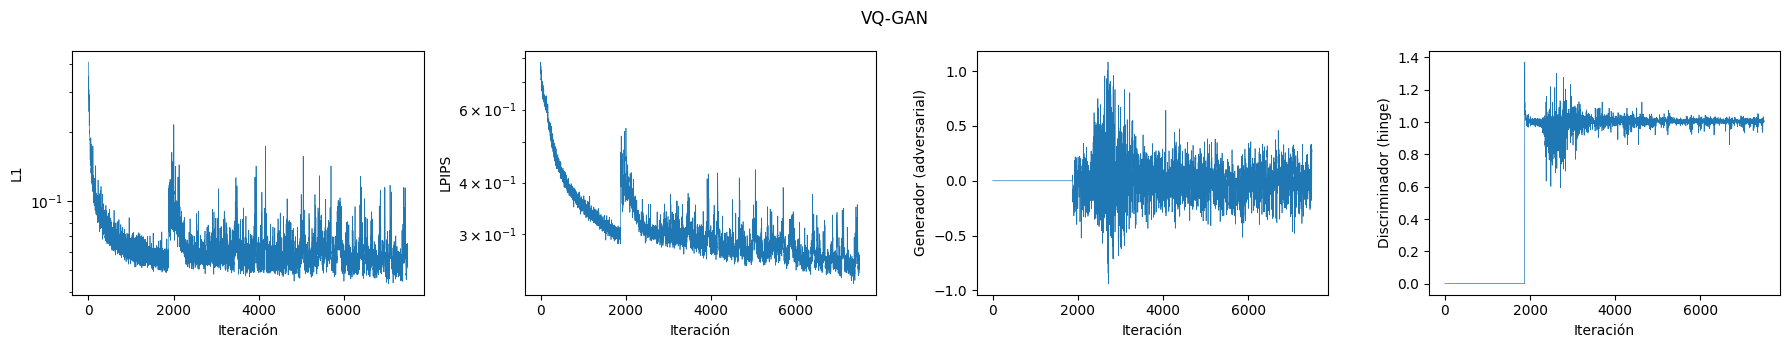

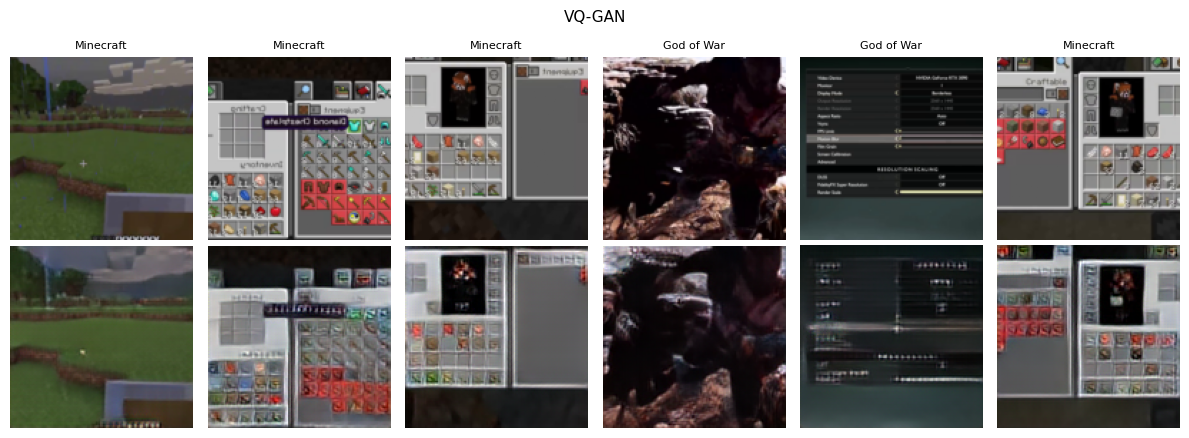

In [ ]:
vqgan = VQVAE(num_codes=512, code_dim=64, num_classes=dataset.num_classes, ch=96)
ckpt  = torch.load('vqgan.pth', map_location=DEVICE, weights_only=False)
vqgan.load_state_dict(ckpt['model_state_dict'])
vqgan.to(DEVICE).eval()

l1, perc, gen, disc = zip(*ckpt['loss_history'])
panels = [
    (l1, 'L1', True),
    (perc, 'LPIPS', True),
    (gen, 'Generador (adversarial)', False),
    (disc, 'Discriminador (hinge)', False),
]
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, (data, label, logy) in zip(axes, panels):
    ax.plot(data, linewidth=0.5)
    if logy:
        ax.set_yscale('log')
    ax.set_xlabel('Iteración'); ax.set_ylabel(label)
plt.suptitle('VQ-GAN'); plt.tight_layout(); plt.show()

show_reconstructions(vqgan, title='VQ-GAN')

# Parte 3: Prior autoregresivo (GPT)

Hasta ahora se ha entrenado un autoencoder que comprime cada imagen en una grilla de $T = H\times W$ índices discretos, $k_1,\ldots,k_T\in\{1,\ldots,K\}$. Sin embargo, para poder generar imágenes nuevas se necesita entrenar un modelo para la distribución conjunta sobre los índices, condicionado por la clase $y\in\{1,\ldots,C\}$. En consecuencia, en esta última parte se entrenará un transformer causal que factorice la distribución de forma autoregresiva:

$$
  p_\psi(k_1,\ldots, k_T\mid y) = p_\psi(k_1|y)\prod_{t=2}^{T} p_\psi(k_t \mid k_1,\ldots, k_{t-1},y)
$$

Luego se muestreará de forma autoregresiva para producir secuencias nuevas. Una vez generada una secuencia $k_1,\ldots,k_T$, se mapeará cada índice a su vector del codebook, y se pasará esta secuencia de vectores por el decoder del VQ-GAN para obtener la imagen final generada.

## 3.1 Arquitectura y sampling

El transformer se implementará usando `nn.TransformerEncoderLayer` en modo pre-LN (`norm_first=True`) y con activación GELU, y se aplicará una máscara causal usando `nn.Transformer.generate_square_subsequent_mask`. Por otro lado, la entrada del transformer en cada posición será la suma del embedding del token (índice del codebook), de un embedding posicional aprendido, y de un embedding de clase $c_\psi(y)\in\mathbb{R}^{d_\text{model}}$ (el mismo para todas las posiciones). Además, se utilizará el token especial $\langle\text{BOS}\rangle$ para luego inicializar la generación autoregresiva.

> Implemente el método `sample` de la clase `TokenGPT`, el cual recibe una etiqueta de clase $y\in\{1,\ldots,C\}$ para cada elemento del batch, y genera una secuencia de `self.seq_len` tokens de forma autorregresiva. En cada step de generación se debe aplicar una temperatura $\tau$ y la heurística top-$K$ sampling. Recuerde inicializar la secuencia con el token $\langle\text{BOS}\rangle$ y omitir su salida al retornar el resultado.

In [ ]:
class TokenGPT(nn.Module):

    def __init__(self, vocab: int = 512, num_classes: int = 2, seq_len: int = 256, d: int = 256, nhead: int = 8, nlayer: int = 6, dropout: float = 0.1) -> None:
        super().__init__()
        self.vocab = vocab
        self.seq_len = seq_len
        self.bos_id = vocab
        self.tok_emb = nn.Embedding(vocab + 1, d)
        self.pos_emb = nn.Parameter(torch.zeros(1, seq_len, d))
        self.class_emb = nn.Embedding(num_classes, d)
        self.drop = nn.Dropout(dropout)
        layer = nn.TransformerEncoderLayer(d, nhead, dim_feedforward=4 * d, dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, nlayer, enable_nested_tensor=False)
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        nn.init.normal_(self.pos_emb, std=0.02)
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Embedding)):
                nn.init.normal_(m.weight, std=0.02)

    def _backbone(self, tokens: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        T = tokens.shape[1]
        h = self.tok_emb(tokens) + self.pos_emb[:, :T] + self.class_emb(y).unsqueeze(1)
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=tokens.device)
        h = self.transformer(self.drop(h), mask=mask, is_causal=True)
        return self.head(self.ln_f(h))

    def forward(self, tokens: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        bos = torch.full((tokens.shape[0], 1), self.bos_id, device=tokens.device, dtype=tokens.dtype)
        inp = torch.cat([bos, tokens[:, :-1]], dim=1)
        return self._backbone(inp, y)

    @torch.no_grad()
    def sample(self, y: torch.Tensor, temperature: float = 1.0, top_k: int | None = None) -> torch.Tensor:
        ...

@torch.no_grad()
def encode_to_tokens(vqvae: VQVAE, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    _, _, indices = vqvae.quantizer(vqvae.encode(x, y))
    return indices.flatten(1)

## 3.2 Entrenamiento

Para entrenar el prior se utilizará la VQ-GAN entrenada como tokenizador (congelado). Más precisamente, dado $(x,y)\sim p_\text{data}(x,y)$, se obtiene la secuencia de entrenamiento, $k_1,\ldots,k_T\in\{1,\ldots,T\}$ aplicando $E_\phi$ seguido de la cuantización al codebook, y se entrena el GPT maximizando, como es usual, la log-verosimilitud condicional:

$$
  \max_\psi\,\mathbb{E}_{p_\text{data}(x,y)}\left[\sum_{t=1}^{T} \log p_\psi(k_t \mid k_1,\ldots, k_{t-1},\,y)\right]
$$

> Implemente la función `train_gpt`, la cual entrena un modelo tipo `TokenGPT` siguiendo la función objetivo anterior, usando un objeto tipo `VQVAE` como tokenizador. Como retorno, la función debe entregar una lista con la evolución de la función de pérdida durante el entrenamiento.

In [ ]:
def train_gpt(gpt: TokenGPT, vqvae: VQVAE, dataloader: DataLoader, epochs: int, lr: float = 3e-4, ckpt_path: str = 'gpt.pth') -> list[float]:
    ...

La siguiente celda instancia el GPT y lo entrena sobre los tokens de la VQ-GAN. Notar que para este entrenamiento no interviene ni el discriminador ni LPIPS, por lo que el entrenamiento consume menos memoria, lo que permite aumentar el batch size para aprovechar mejor la GPU y acelerar el entrenamiento. Para esto eso se reinstancia nuevamente el dataloader antes de entrenar:

In [ ]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2, drop_last=True)

gpt = TokenGPT(vocab=vqgan.num_codes, num_classes=dataset.num_classes, seq_len=(dataset.img_size // 8) ** 2, d=256, nhead=8, nlayer=6, dropout=0.1)
print(f'Parámetros GPT: {sum(p.numel() for p in gpt.parameters())/1e6:.2f} M')

train_gpt(gpt, vqgan, dataloader, epochs=500, ckpt_path='gpt_vqgan.pth')
free_memory()

Parámetros GPT: 5.07 M


GPT prior: 100%|██████████| 500/500 [13:29<00:00,  1.62s/it, loss=4.2942]


## 3.3 Generación de muestras

Finalmente, se cargará el modelo autorregresivo entrenado y se generarán imágenes nuevas. Dada una clase $y\in\{1,\ldots,C\}$, el proceso de generación es el siguiente:

1. Muestrear $k_1\ldots,k_T\sim p_\psi(k_1,\ldots,k_T\mid y)$ de forma autoregresiva comenzando con el token $\langle\text{BOS}\rangle$.
2. Mapear cada índice $k_t\in\{1,\ldots, K\}$ a su vector del codebook, $e_{k_t}\in\mathbb{R}^{L}$.
3. Reorganizar la secuencia plana en una grilla $z_q\in\mathbb{R}^{L\times H\times W}$ y pasar esta grilla por el decoder de la VQ-GAN para obtener $\hat{x}=D_\theta(z_q,\,y)$.

> Implemente la función `sample_images`, la cual genera un batch de imágenes nuevas usando el proceso descrito arriba.

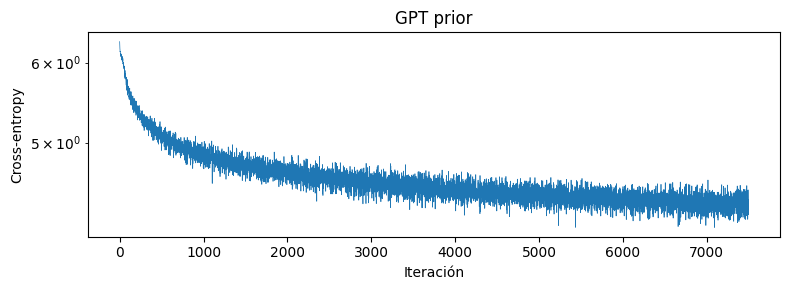

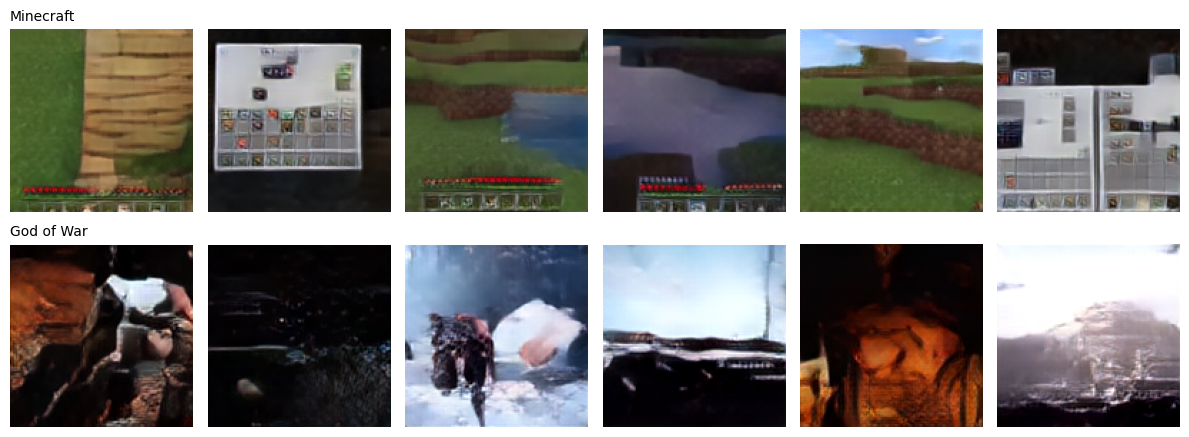

In [ ]:
gpt = TokenGPT(vocab=vqgan.num_codes, num_classes=dataset.num_classes, seq_len=(dataset.img_size // 8) ** 2, d=256, nhead=8, nlayer=6, dropout=0.1)
ckpt = torch.load('gpt_vqgan.pth', map_location=DEVICE, weights_only=False)
gpt.load_state_dict(ckpt['model_state_dict'])
gpt.to(DEVICE).eval()

plt.figure(figsize=(8, 3))
plt.plot(ckpt['loss_history'], linewidth=0.5)
plt.xlabel('Iteración'); plt.ylabel('Cross-entropy'); plt.yscale('log'); plt.title('GPT prior')
plt.tight_layout(); plt.show()

@torch.no_grad()
def sample_images(gpt: TokenGPT, vqvae: VQVAE, class_idx: int, n: int = 6, temperature: float = 1.0, top_k: int = 100) -> torch.Tensor:
    ...

n_per_class = 6
fig, axes = plt.subplots(dataset.num_classes, n_per_class, figsize=(2 * n_per_class, 2.3 * dataset.num_classes))
for c, name in enumerate(dataset.class_names):
    imgs = sample_images(gpt, vqgan, class_idx=c, n=n_per_class)
    for j in range(n_per_class):
        ax = axes[c, j] if dataset.num_classes > 1 else axes[j]
        ax.imshow(imgs[j].permute(1, 2, 0)); ax.axis('off')
        if j == 0: ax.set_title(name, fontsize=10, loc='left')
plt.tight_layout(); plt.show()